**Import necessary libraries**



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle
from skimage.transform import resize
import glob
from sklearn.model_selection import train_test_split
import tensorflow_hub as hub
from tensorflow import keras
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


**Loading dataset**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

import zipfile

zip_path = '/content/drive/MyDrive/Cotton plant.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/dataset')

print("Done! Files extracted.")

Done! Files extracted.


In [4]:
import os

for f in os.listdir('/content/dataset'):
    print(f)

Cotton plant


In [5]:
dataset_path = '/content/dataset'

In [6]:
aphids=glob.glob('/content/dataset/Cotton plant/Aphids/*.*')
healthy_leaf=glob.glob('/content/dataset/Cotton plant/Healthy/*.*')
bacterial_blight=glob.glob('/content/dataset/Cotton plant/Bacterial Blight/*.*')
army_worm=glob.glob('/content/dataset/Cotton plant/Army worm/*.*')
target_spot=glob.glob('/content/dataset/Cotton plant/Target spot/*.*')
powdery_mildew=glob.glob('/content/dataset/Cotton plant/Powdery Mildew/*.*')

In [7]:
print(len(aphids))
print(len(healthy_leaf))
print(len(bacterial_blight))
print(len(army_worm))
print(len(target_spot))
print(len(powdery_mildew))

400
400
400
400
400
400


**Assigning classes to dataset**

In [8]:
classes={0:'aphids',1:'healthy_leaf',2:'bacterial_blight',3:'army_worm',4:'target_spot',5:'powdery_mildew'}

**Reading images and storing it**

In [12]:

import gc

total=(len(aphids) + len(healthy_leaf) + len(bacterial_blight) +
         len(army_worm) + len(target_spot)+len(powdery_mildew))
X = np.zeros((total, 224, 224, 3), dtype=np.float32)
y = []
idx = 0

for img_path in aphids:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(0)
    idx += 1

for img_path in healthy_leaf:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(1)
    idx += 1

for img_path in bacterial_blight:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(2)
    idx += 1

for img_path in army_worm:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(3)
    idx += 1

for img_path in target_spot:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(4)
    idx += 1

for img_path in powdery_mildew:
    X[idx] = resize(plt.imread(img_path), (224, 224, 3))
    y.append(5)
    idx += 1

y = np.array(y)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2400, 224, 224, 3)
y shape: (2400,)


**Shuffling data**

In [13]:
X,y=shuffle(X,y,random_state=42)

**Visualizing some of the images**

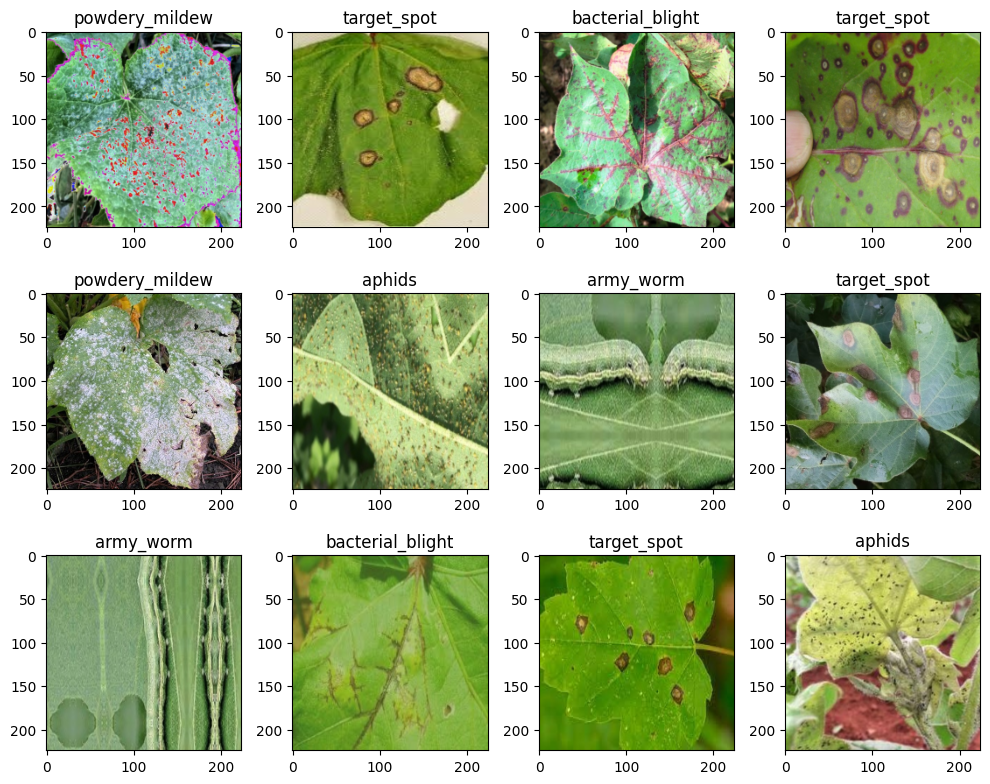

In [14]:
plt.figure(figsize=(10,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(X[i])
  plt.title(classes[y[i]])
plt.tight_layout()

**Train test split**

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

**MobileNetV2 Pre-trained Feature Extractor Model**

In [16]:
feature_extractor_model= "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

**Load Pre-trained MobileNetV2 Feature Extractor Mode**

In [17]:
hub.load(feature_extractor_model)

<tensorflow.python.saved_model.load.Loader._recreate_base_user_object.<locals>._UserObject at 0x79dab7451eb0>

In [18]:
pre_model=hub.KerasLayer(feature_extractor_model,input_shape=(224,224,3),trainable=False)

In [19]:
np.unique(y_train)

array([0, 1, 2, 3, 4, 5])

In [20]:
from tensorflow.keras import Sequential,layers

**Defining number of output classes**

In [21]:
num_of_classes=6

**Model Creation**

In [26]:
model=Sequential([
    layers.InputLayer(input_shape=(224,224,3)),
    layers.Lambda(lambda x: pre_model(x)),

    layers.Dense(64,activation='relu'),
    layers.Dropout(0.6),

    layers.Dense(14,activation='relu'),
    layers.Dense(num_of_classes,activation='softmax')
])

In [27]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 14)             │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,984 (324.16 KB)

 Trainable params: 82,984 (324.16 KB)

 Non-trainable params: 0 (0.00 B)

**Training**

In [29]:
model.fit(X_train,y_train,epochs=20,validation_split=0.1)

Epoch 1/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 13s 122ms/step - accuracy: 0.3021 - loss: 1.6920 - val_accuracy: 0.6406 - val_loss: 1.2245
Epoch 2/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5365 - loss: 1.2392 - val_accuracy: 0.7969 - val_loss: 0.7633
Epoch 3/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.6782 - loss: 0.8911 - val_accuracy: 0.8802 - val_loss: 0.5483
Epoch 4/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7512 - loss: 0.6931 - val_accuracy: 0.8906 - val_loss: 0.3960
Epoch 5/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.7980 - loss: 0.5650 - val_accuracy: 0.9271 - val_loss: 0.3017
Epoch 6/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.8351 - loss: 0.4675 - val_accuracy: 0.9271 - val_loss: 0.2372
Epoch 7/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8588 - loss: 0.4127 - val_accuracy: 0.9531 - val_loss: 0.1760
Epoch 8/20
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8744 - loss: 0.3645 - val_accuracy: 0.9375 -

In [30]:
training_loss,training_acc=model.evaluate(X_train,y_train)
print('training loss:',training_loss)
print('training accuracy:',training_acc)

60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9932 - loss: 0.0223
training loss: 0.02231845073401928
training accuracy: 0.9932291507720947


In [31]:
testing_loss,testing_acc=model.evaluate(X_test,y_test)
print('testing loss:',testing_loss)
print('testing accuracy:',testing_acc)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9563 - loss: 0.1182
testing loss: 0.11820243299007416
testing accuracy: 0.956250011920929


**Making predictions**

In [32]:
y_pred=model.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step


In [33]:
pred=[np.argmax(i) for i in y_pred]

**Visualising output with test data**

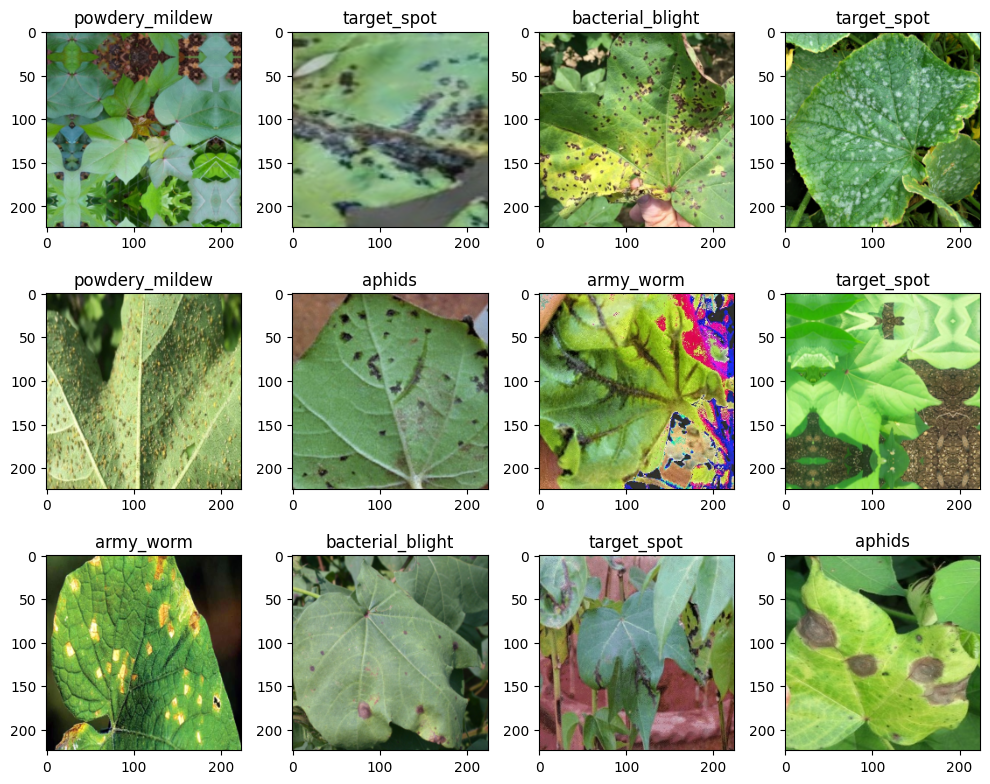

In [37]:
plt.figure(figsize=(10,8))
for i in range(12):
  plt.subplot(3,4,i+1)
  plt.imshow(X_test[i])
  plt.title(classes[y[i]])
plt.tight_layout()

**Evaluation metrics**

In [34]:
accuracy_score(y_test,pred)

0.95625

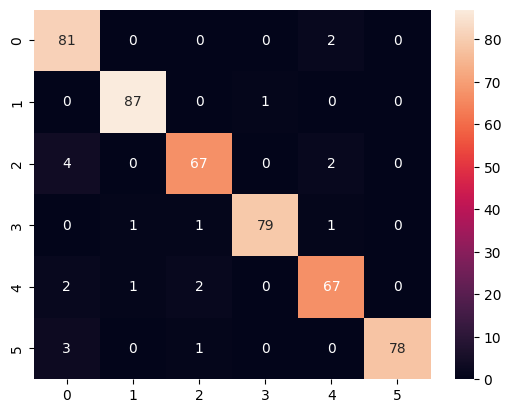

In [35]:
sns.heatmap(confusion_matrix(y_test,pred),annot=True,fmt='d')
plt.show()

In [36]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94        83
           1       0.98      0.99      0.98        88
           2       0.94      0.92      0.93        73
           3       0.99      0.96      0.98        82
           4       0.93      0.93      0.93        72
           5       1.00      0.95      0.97        82

    accuracy                           0.96       480
   macro avg       0.96      0.95      0.96       480
weighted avg       0.96      0.96      0.96       480

